In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Load embeddings & metadata
emb = np.load("../results/embeddings_stratified.npy")
meta = pd.read_csv("../results/metadata_stratified.csv")

# ─── Ensure we’re using stratified data ───
EMBED_PATH = "../results/embeddings_stratified.npy"
META_PATH  = "../results/metadata_stratified.csv"
emb = np.load(EMBED_PATH)
meta = pd.read_csv(META_PATH)

# Quick check
print("Embedding shape:", emb.shape)
print("Genre counts:", meta.tag.value_counts().to_dict())
genres = meta["tag"].unique()
within_means = []
across_means = []

# For each genre, sample 2000 random within‐genre and across‐genre pairs
for g in genres:
    idxs       = meta.index[meta.tag == g].to_numpy()
    other_idxs = meta.index[meta.tag != g].to_numpy()
    # sample with replacement
    wi_i = np.random.choice(idxs, size=2000, replace=True)
    wi_j = np.random.choice(idxs, size=2000, replace=True)
    ac_i = np.random.choice(idxs, size=2000, replace=True)
    ac_j = np.random.choice(other_idxs, size=2000, replace=True)

    # compute cosine similarities
    sims_within = np.einsum('ij,ij->i', emb[wi_i], emb[wi_j]) \
                  / (np.linalg.norm(emb[wi_i], axis=1) * np.linalg.norm(emb[wi_j], axis=1))
    sims_across = np.einsum('ij,ij->i', emb[ac_i], emb[ac_j]) \
                  / (np.linalg.norm(emb[ac_i], axis=1) * np.linalg.norm(emb[ac_j], axis=1))

    within_means.append(sims_within.mean())
    across_means.append(sims_across.mean())

# Convert to numpy arrays for plotting
within_means = np.array(within_means)
across_means = np.array(across_means)

Embedding shape: (30000, 768)
Genre counts: {'country': 5000, 'misc': 5000, 'pop': 5000, 'rap': 5000, 'rb': 5000, 'rock': 5000}


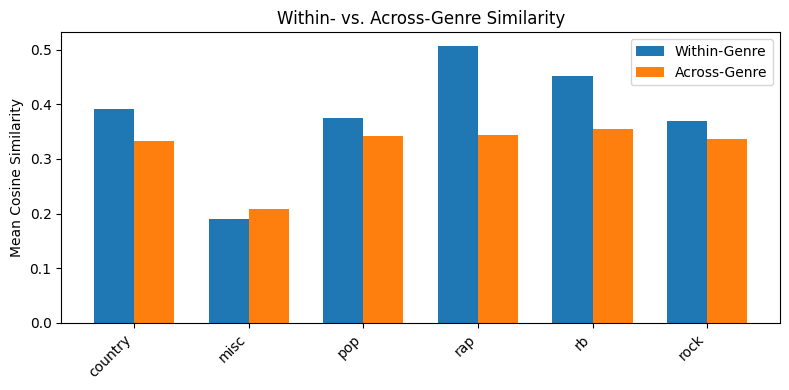

In [20]:
import matplotlib.pyplot as plt
import numpy as np

x     = np.arange(len(genres))
width = 0.35

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, within_means, width, label="Within-Genre")
ax.bar(x + width/2, across_means,  width, label="Across-Genre")
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha="right")
ax.set_ylabel("Mean Cosine Similarity")
ax.set_title("Within- vs. Across-Genre Similarity")
ax.legend()
plt.tight_layout()
plt.show()

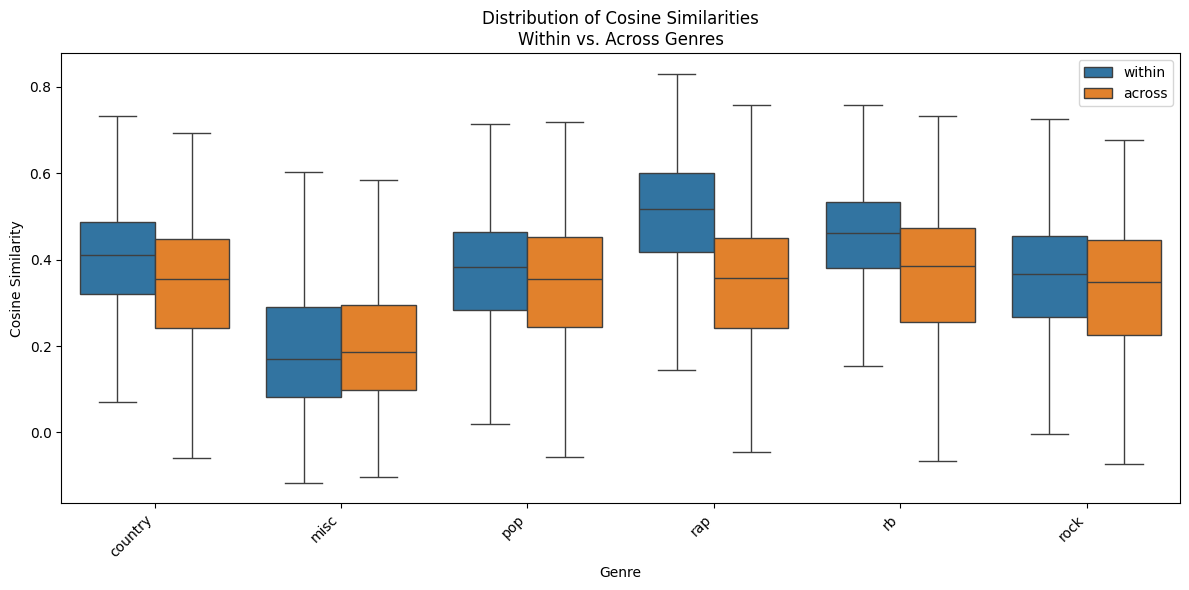

In [21]:
# 1) (Re)compute sims_within_list & sims_across_list

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Load embeddings & metadata

genres = meta["tag"].unique()
sims_within_list = []
sims_across_list = []

for g in genres:
    idxs       = meta.index[meta.tag == g].to_numpy()
    other_idxs = meta.index[meta.tag != g].to_numpy()

    # sample pairs
    wi_i = np.random.choice(idxs, size=2000, replace=True)
    wi_j = np.random.choice(idxs, size=2000, replace=True)
    ac_i = np.random.choice(idxs, size=2000, replace=True)
    ac_j = np.random.choice(other_idxs, size=2000, replace=True)

    # compute cosine similarities
    sims_within = np.einsum('ij,ij->i', emb[wi_i], emb[wi_j]) \
                  / (np.linalg.norm(emb[wi_i], axis=1) * np.linalg.norm(emb[wi_j], axis=1))
    sims_across = np.einsum('ij,ij->i', emb[ac_i], emb[ac_j]) \
                  / (np.linalg.norm(emb[ac_i], axis=1) * np.linalg.norm(emb[ac_j], axis=1))

    sims_within_list.append(sims_within)
    sims_across_list.append(sims_across)

# 2) Build a DataFrame for plotting
records = []
for genre, within, across in zip(genres, sims_within_list, sims_across_list):
    records += [{"genre": genre, "type": "within", "sim": s} for s in within]
    records += [{"genre": genre, "type": "across",  "sim": s} for s in across]

df_sims = pd.DataFrame(records)

# 3) Plot boxplots
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(x="genre", y="sim", hue="type", data=df_sims, showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Genre")
plt.ylabel("Cosine Similarity")
plt.title("Distribution of Cosine Similarities\nWithin vs. Across Genres")
plt.legend(title="")
plt.tight_layout()
plt.show()

In [22]:
# ─── Cell: (Re)define clustering & classification ───
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# 1) Load embeddings & metadata

# 2) Clustering setup
genres = meta["tag"].unique()
km = KMeans(n_clusters=len(genres), random_state=42).fit(emb)
# km.labels_ is now available for the confusion matrix

# 3) Classification setup
X_train, X_test, y_train, y_test = train_test_split(
    emb, meta["tag"], test_size=0.2, random_state=42, stratify=meta["tag"]
)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
# you can now call knn.predict(X_test) for the classification report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

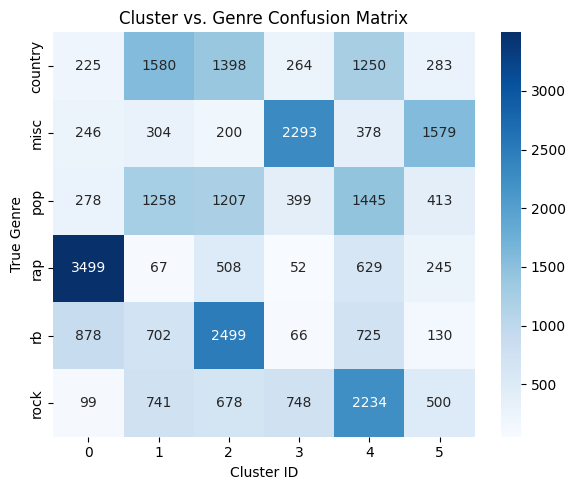

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Load embeddings & metadata and re-fit KMeans
genres = meta["tag"].unique()

from sklearn.cluster import KMeans
km = KMeans(n_clusters=len(genres), random_state=42).fit(emb)

# 2) Build the crosstab: rows=true genre, columns=cluster ID
ct = pd.crosstab(meta["tag"], km.labels_,
                 rownames=["True Genre"], colnames=["Cluster ID"])

# 3) Plot it
plt.figure(figsize=(6,5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Cluster vs. Genre Confusion Matrix")
plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.metrics      import classification_report

# 1) Split and train
X_train, X_test, y_train, y_test = train_test_split(
    emb, meta["tag"], test_size=0.2, random_state=42, stratify=meta["tag"]
)
knn = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn.fit(X_train, y_train)

# 2) Predict and report
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred, target_names=genres, zero_division=0))

              precision    recall  f1-score   support

     country       0.52      0.54      0.53      1000
        misc       0.83      0.67      0.74      1000
         pop       0.30      0.21      0.25      1000
         rap       0.59      0.81      0.68      1000
          rb       0.44      0.49      0.46      1000
        rock       0.45      0.42      0.44      1000

    accuracy                           0.52      6000
   macro avg       0.52      0.52      0.52      6000
weighted avg       0.52      0.52      0.52      6000



/Users/bhechmer/utk_classes/spring25/data_mining/song-theme-similarity/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/bhechmer/utk_classes/spring25/data_mining/song-theme-similarity/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


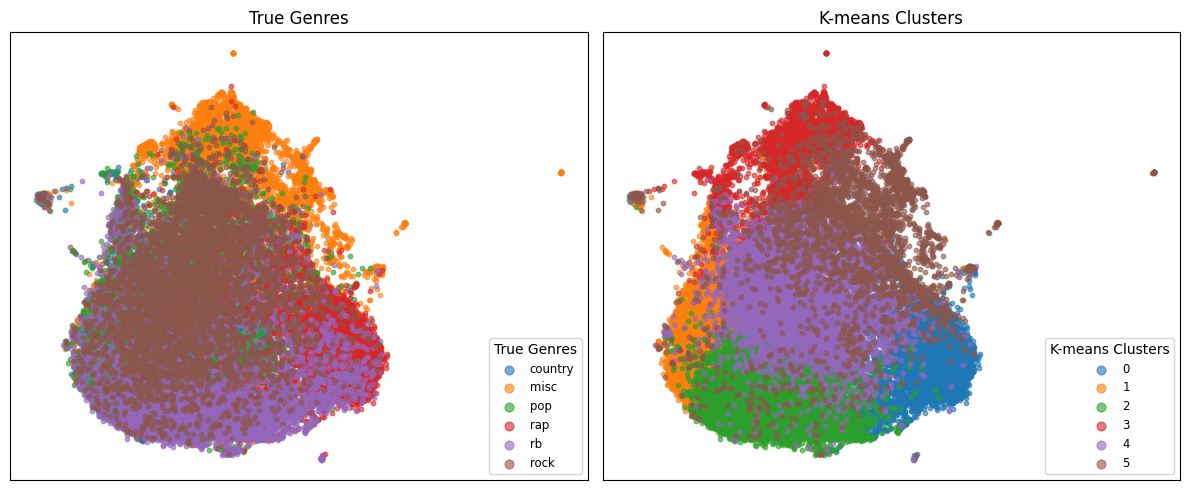

In [25]:
import umap
import matplotlib.pyplot as plt

# 1) Compute 2D UMAP projections (once)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb2d  = reducer.fit_transform(emb)

# 2) Plot panels
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)

for ax, labels, title in zip(
    axes,
    [meta["tag"], km.labels_],
    ["True Genres", "K-means Clusters"]
):
    for lab in np.unique(labels):
        mask = (labels == lab)
        ax.scatter(emb2d[mask,0], emb2d[mask,1], s=10, alpha=0.6, label=str(lab))
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(markerscale=2, fontsize="small", title=title)

plt.tight_layout()
plt.show()